In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import  train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report


In [2]:
data = pd.read_csv('titanic3.csv')

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   pclass     1309 non-null   int64  
 1   survived   1309 non-null   int64  
 2   name       1309 non-null   object 
 3   sex        1309 non-null   object 
 4   age        1046 non-null   float64
 5   sibsp      1309 non-null   int64  
 6   parch      1309 non-null   int64  
 7   ticket     1309 non-null   object 
 8   fare       1308 non-null   float64
 9   cabin      295 non-null    object 
 10  embarked   1307 non-null   object 
 11  boat       486 non-null    object 
 12  body       121 non-null    float64
 13  home.dest  745 non-null    object 
dtypes: float64(3), int64(4), object(7)
memory usage: 143.3+ KB


In [4]:
data.isna().sum()

pclass          0
survived        0
name            0
sex             0
age           263
sibsp           0
parch           0
ticket          0
fare            1
cabin        1014
embarked        2
boat          823
body         1188
home.dest     564
dtype: int64

In [5]:
# Fill empty values in Age - Median of Age in each class
data['age'].fillna(data.groupby(['pclass','sex'])['age'].transform('median'), inplace = True)

In [6]:
# Fill empty values in Fare - Median of Fare in each class
data['fare'].fillna(data.groupby(['pclass'])['fare'].transform('median'), inplace = True)

<Axes: xlabel='survived', ylabel='fare'>

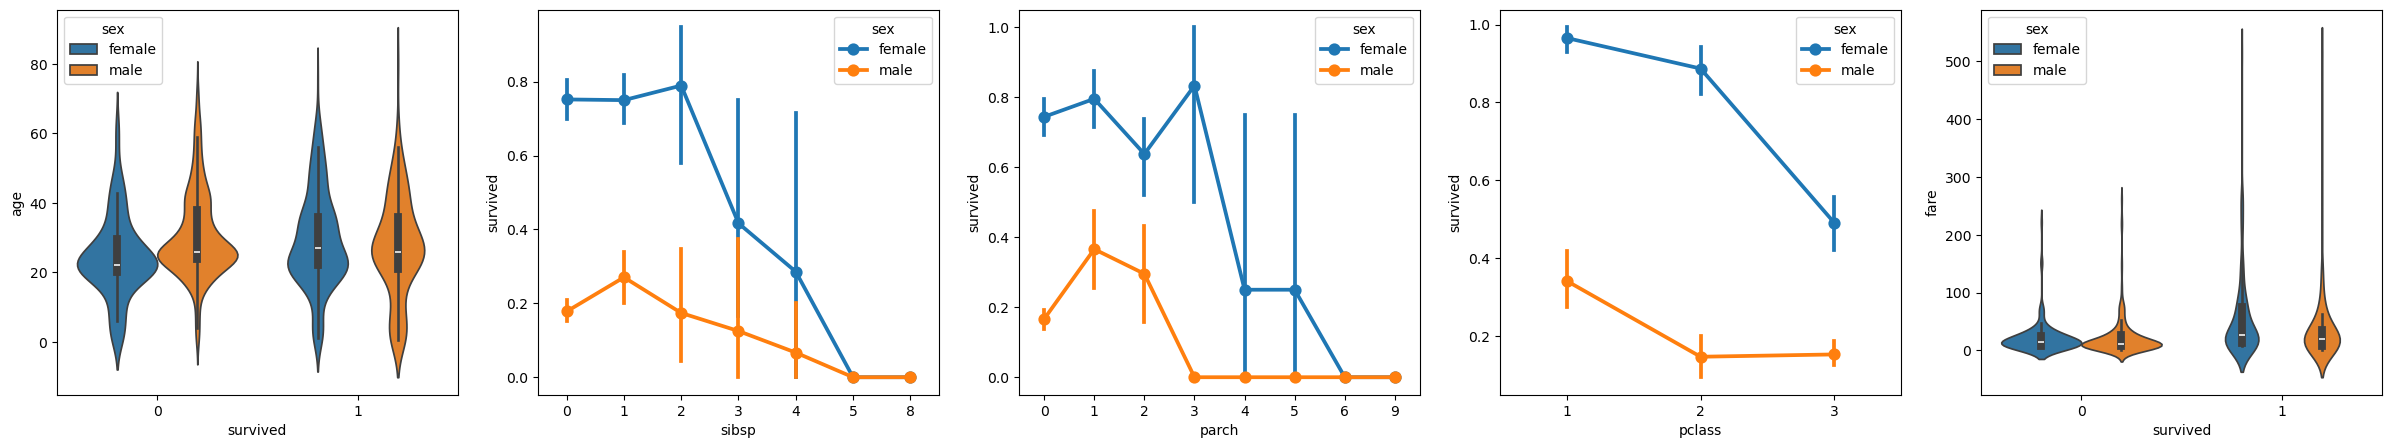

In [7]:
fig,axs = plt.subplots(ncols=5, figsize=(30,5))
sns.violinplot(x='survived',y='age',hue='sex', data=data, ax=axs[0])
sns.pointplot(x='sibsp',y='survived', hue='sex', data=data, ax=axs[1])
sns.pointplot(x='parch',y='survived', hue='sex', data=data, ax=axs[2])
sns.pointplot(x='pclass',y='survived', hue='sex', data=data, ax=axs[3])
sns.violinplot(x='survived',y='fare',hue='sex', data=data, ax=axs[4])


In [8]:
data['sex'].replace({'male':1,'female':0}, inplace=True)
data.embarked.fillna('U',inplace = True)
data['embarked'].replace({'C':0,'Q':1,'S':2,'U':2}, inplace = True)

In [9]:
data.corr(numeric_only=True).abs()[['survived']]

,survived
pclass,0.312469
survived,1.000000
sex,0.528693
age,0.034224
sibsp,0.027825
parch,0.082660
fare,0.244479
embarked,0.175313
body,NaN


In [10]:
data['relatives']=data.apply(lambda row: int((row['sibsp']+row['parch'])>0),axis=1)



In [11]:
data.corr(numeric_only=True).abs()[['survived']]

,survived
pclass,0.312469
survived,1.000000
sex,0.528693
age,0.034224
sibsp,0.027825
parch,0.082660
fare,0.244479
embarked,0.175313
body,NaN
relatives,0.201719


In [12]:
data = data[['sex','age','pclass','relatives','fare','embarked','survived']].dropna()

In [13]:
data = data.astype({"age": np.float64, "fare": np.float64})

In [14]:
y=data['survived']
X=data.drop(columns=['survived'])

In [15]:
train_X,test_X,train_y,test_y = train_test_split(X,y,test_size=0.2,random_state=42)

In [16]:
scaler = StandardScaler()
train_X = scaler.fit_transform(train_X)
test_X = scaler.transform(test_X)

In [17]:
model = LogisticRegression(max_iter=1000)
model.fit(train_X,train_y)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [18]:
train_pred = model.predict(train_X)
test_pred = model.predict(test_X)

In [19]:
print(accuracy_score(train_y, train_pred))
print(accuracy_score(test_y, test_pred))
print('-----****************************------')
print(classification_report(train_y, train_pred))
print(classification_report(test_y, test_pred))
print('-----****************************------')
print(confusion_matrix(train_y, train_pred))
print('-----****************************------')
print(confusion_matrix(test_y, test_pred))

0.789875835721108
0.7786259541984732
-----****************************------
              precision    recall  f1-score   support

           0       0.83      0.85      0.84       665
           1       0.72      0.69      0.71       382

    accuracy                           0.79      1047
   macro avg       0.77      0.77      0.77      1047
weighted avg       0.79      0.79      0.79      1047

              precision    recall  f1-score   support

           0       0.75      0.89      0.82       144
           1       0.83      0.64      0.72       118

    accuracy                           0.78       262
   macro avg       0.79      0.77      0.77       262
weighted avg       0.79      0.78      0.77       262

-----****************************------
[[562 103]
 [117 265]]
-----****************************------
[[128  16]
 [ 42  76]]
